In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Medicaldataset.csv')
print(data)

      Age  Gender  Heart rate  Systolic blood pressure  \
0      63       1          66                      160   
1      20       1          94                       98   
2      56       1          64                      160   
3      66       1          70                      120   
4      54       1          64                      112   
...   ...     ...         ...                      ...   
1314   44       1          94                      122   
1315   66       1          84                      125   
1316   45       1          85                      168   
1317   54       1          58                      117   
1318   51       1          94                      157   

      Diastolic blood pressure  Blood sugar  CK-MB  Troponin    Result  
0                           83        160.0   1.80     0.012  negative  
1                           46        296.0   6.75     1.060  positive  
2                           77        270.0   1.99     0.003  negative  
3          

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB
None
               Age       Gender   Heart rate  Systolic blood pressure  \
count  1319.000000  1319.000000  1319.000000              1319.000000   
mean     56.193328     0.659591    78.336619               127.170584   
st

In [ ]:
# Check missing values
data.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


In [ ]:
# Check for duplicate records, delete if present and check the data shape
print("Duplicate rows:", data.duplicated().sum())
data.drop_duplicates(inplace=True)
print("Dataset shape after cleaning:", data.shape)


Duplicate rows: 0
Dataset shape after cleaning: (1319, 9)


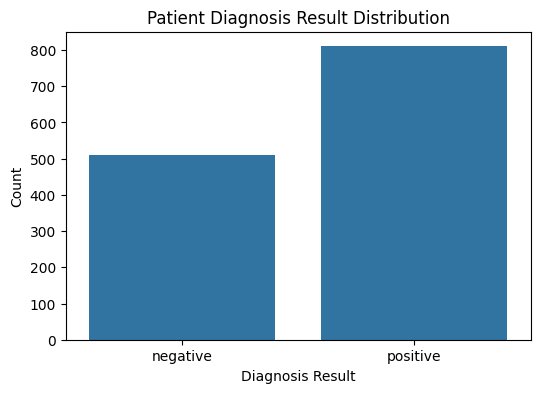

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Result', data=data)
plt.title('Patient Diagnosis Result Distribution')
plt.xlabel('Diagnosis Result')
plt.ylabel('Count')
plt.show()

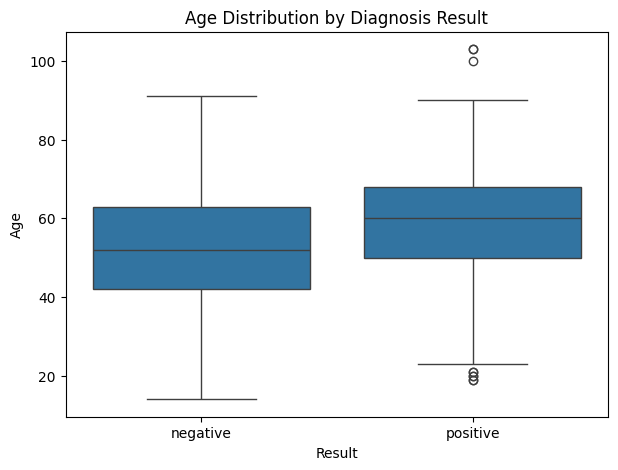

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Result', y='Age', data=data)
plt.title('Age Distribution by Diagnosis Result')
plt.show()

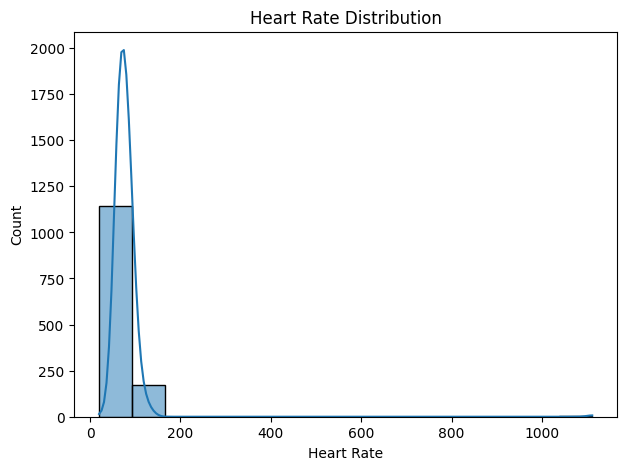

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(data['Heart rate'], bins=15, kde=True)
plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate')
plt.show()

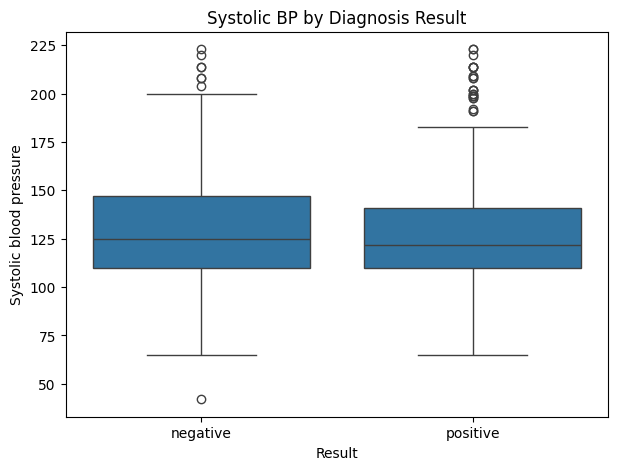

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Result', y='Systolic blood pressure', data=data)
plt.title('Systolic BP by Diagnosis Result')
plt.show()


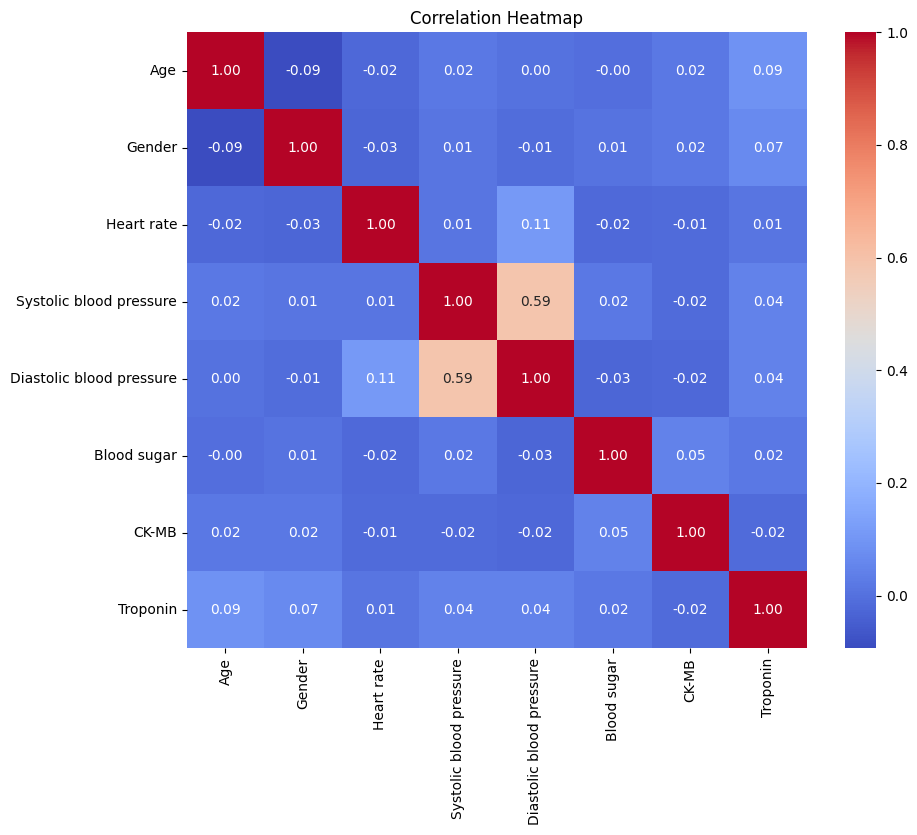

In [ ]:
numerical_cols = data.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
data['Risk_Level'] = (
    (data['Systolic blood pressure'] >= 140) |
    (data['Blood sugar'] >= 200) |
    (data['Troponin'] > 0.4)
).astype(int)


In [ ]:
data['Risk_Level'].value_counts()

,count
Risk_Level,
1,686
0,633


In [ ]:
bed_percentage = data['Risk_Level'].mean() * 100
print(f"Estimated {bed_percentage:.2f}% of patients may require hospital beds")


Estimated 52.01% of patients may require hospital beds


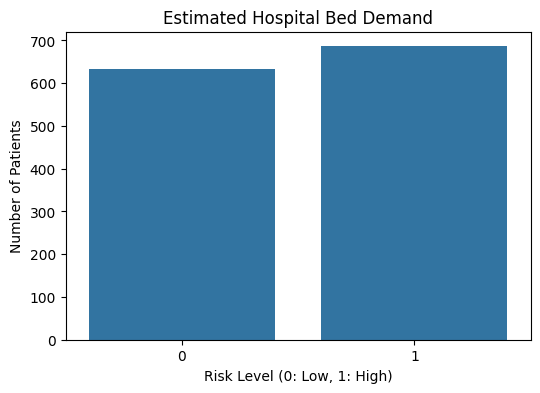

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Level', data=data)
plt.title('Estimated Hospital Bed Demand')
plt.xlabel('Risk Level (0: Low, 1: High)')
plt.ylabel('Number of Patients')
plt.show()

In [ ]:
#Feature Selection
X = data.drop(columns=['Risk_Level', 'Result', 'BP_Level', 'Troponin'], errors='ignore')
y = data['Risk_Level']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.82      1.00      0.90       127
           1       1.00      0.80      0.89       137

    accuracy                           0.89       264
   macro avg       0.91      0.90      0.89       264
weighted avg       0.91      0.89      0.89       264



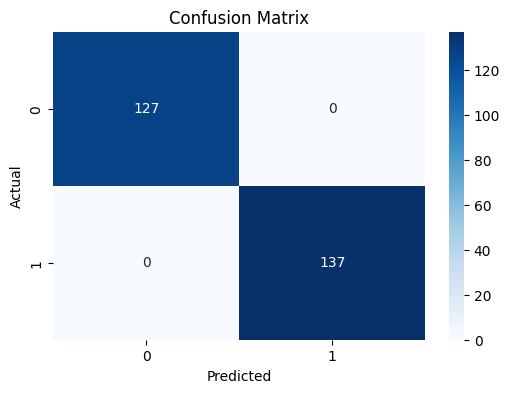

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
